Connect to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Connect Ke folder

In [ ]:
import os
# Cek isi direktori MyDrive
print(os.listdir('/content/drive/MyDrive/DML/Data_mining_lanjut'))


['Dataset - Danu', 'Dataset - Irsyad', 'Dataset-Ilza', 'Dataset-Ilza_JPG', 'cluster_labu_siam.csv']


Connect Folder Di Tuju

In [ ]:
import os

path = '/content/drive/MyDrive/DML/Data_mining_lanjut/Dataset-Ilza'
print(os.listdir(path))


['IMG_7621.HEIC', 'IMG_7618.HEIC', 'IMG_7602.HEIC', 'IMG_7576.HEIC', 'IMG_7650.HEIC', 'IMG_7570.HEIC', 'IMG_7622.HEIC', 'IMG_7548.HEIC', 'IMG_7655.HEIC', 'IMG_7592.HEIC', 'IMG_7580.HEIC', 'IMG_7616.HEIC', 'IMG_7617.HEIC', 'IMG_7646.HEIC', 'IMG_7571.HEIC', 'IMG_7619.HEIC', 'IMG_7584.HEIC', 'IMG_7595.HEIC', 'IMG_7654.HEIC', 'IMG_7623.HEIC', 'IMG_7648.HEIC', 'IMG_7645.HEIC', 'IMG_7652.HEIC', 'IMG_7653.HEIC', 'IMG_7597.HEIC', 'IMG_7521.HEIC', 'IMG_7640.HEIC', 'IMG_7641.HEIC', 'IMG_7634.HEIC', 'IMG_7578.HEIC', 'IMG_7568.HEIC', 'IMG_7563.HEIC', 'IMG_7649.HEIC', 'IMG_7582.HEIC', 'IMG_7583.HEIC', 'IMG_7613.HEIC', 'IMG_7609.HEIC', 'IMG_7579.HEIC', 'IMG_7515.HEIC', 'IMG_7647.HEIC', 'IMG_7588.HEIC', 'IMG_7607.HEIC', 'IMG_7562.HEIC', 'IMG_7599.HEIC', 'IMG_7632.HEIC', 'IMG_7657.HEIC', 'IMG_7612.HEIC', 'IMG_7524.HEIC', 'IMG_7518.HEIC', 'IMG_7513.HEIC', 'IMG_7600.HEIC', 'IMG_7625.HEIC', 'IMG_7642.HEIC', 'IMG_7610.HEIC', 'IMG_7590.HEIC', 'IMG_7630.HEIC', 'IMG_7658.HEIC', 'IMG_7656.HEIC', 'IMG_7547.HEI

Merubah File dari HEIC Menjadi JPEG

In [ ]:
!pip install pyheif pillow

import os
import pyheif
from PIL import Image

source_folder = '/content/drive/MyDrive/DML/Data_mining_lanjut/Dataset-Ilza'
output_folder = '/content/drive/MyDrive/DML/Data_mining_lanjut/Dataset-Ilza JPG'

os.makedirs(output_folder, exist_ok=True)

for file_name in os.listdir(source_folder):
    if file_name.lower().endswith('.heic'):
        heif_path = os.path.join(source_folder, file_name)
        image = pyheif.read(heif_path)
        pil_img = Image.frombytes(
            image.mode, image.size, image.data, "raw", image.mode
        )
        output_path = os.path.join(output_folder, file_name.replace('.HEIC', '.jpg'))
        pil_img.save(output_path, format="JPEG")

print("Konversi selesai.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 33.1 MB/s eta 0:00:00
Konversi selesai.


Debug File

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/DML/Data_mining_lanjut'))


['Dataset - Danu', 'Dataset - Irsyad', 'Dataset-Ilza', 'Dataset-Ilza JPG', 'Dataset-Resize']


Pre-processing

Memproses gambar:   0%|          | 0/1016 [00:00<?, ?it/s]

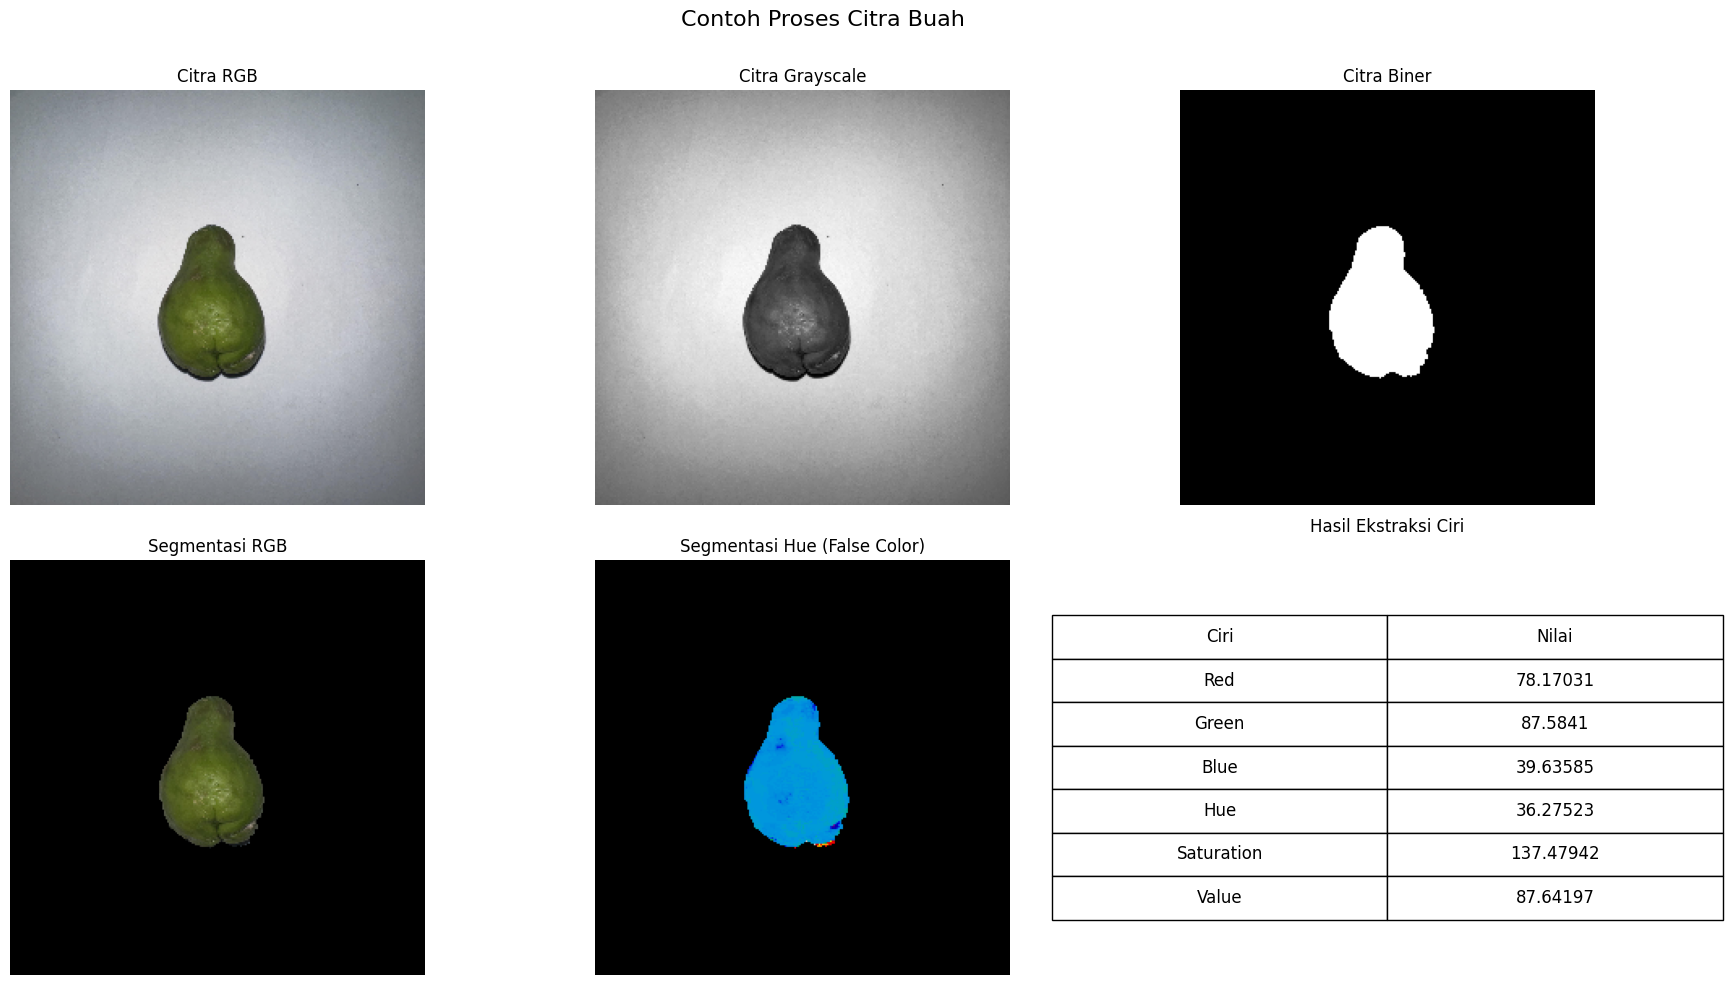

Memproses gambar: 100%|██████████| 1016/1016 [01:53<00:00,  8.98it/s]


Fitur berhasil disimpan di: /content/fitur_labu_siam.csv


In [ ]:
# === BAGIAN 1: IMPORT DAN SETUP ===
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# Folder input dan output
input_folder = '/content/drive/MyDrive/DML/Data_mining_lanjut/Dataset-Ilza JPG'
output_csv = '/content/fitur_labu_siam.csv'

# === BAGIAN 2: DEFINISI FUNGSI ===
def resize_gambar(image, target_size=(256, 256)):
    return cv2.resize(image, target_size)

def segmentasi_buah(image_bgr):
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lower_hsv = np.array([10, 40, 40])
    upper_hsv = np.array([180, 255, 255])
    mask = cv2.inRange(image_hsv, lower_hsv, upper_hsv)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def ekstrak_fitur(image_path):
    image_bgr = cv2.imread(image_path)
    image_resized = resize_gambar(image_bgr)

    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)
    mask = segmentasi_buah(image_resized)

    buah_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    buah_hsv = cv2.bitwise_and(image_hsv, image_hsv, mask=mask)

    buah_rgb_pixels = buah_rgb[mask > 0]
    buah_hsv_pixels = buah_hsv[mask > 0]

    mean_r = np.mean(buah_rgb_pixels[:, 0])
    mean_g = np.mean(buah_rgb_pixels[:, 1])
    mean_b = np.mean(buah_rgb_pixels[:, 2])
    mean_h = np.mean(buah_hsv_pixels[:, 0])
    mean_s = np.mean(buah_hsv_pixels[:, 1])
    mean_v = np.mean(buah_hsv_pixels[:, 2])

    return {
        'filename': os.path.basename(image_path),
        'mean_r': round(mean_r, 5),
        'mean_g': round(mean_g, 5),
        'mean_b': round(mean_b, 5),
        'mean_h': round(mean_h, 5),
        'mean_s': round(mean_s, 5),
        'mean_v': round(mean_v, 5)
    }

def tampilkan_visualisasi_contoh(image_path):
    image_bgr = cv2.imread(image_path)
    image_resized = resize_gambar(image_bgr)

    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)
    mask = segmentasi_buah(image_resized)

    buah_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    buah_hsv = cv2.bitwise_and(image_hsv, image_hsv, mask=mask)

    buah_rgb_pixels = buah_rgb[mask > 0]
    buah_hsv_pixels = buah_hsv[mask > 0]

    mean_r = np.mean(buah_rgb_pixels[:, 0])
    mean_g = np.mean(buah_rgb_pixels[:, 1])
    mean_b = np.mean(buah_rgb_pixels[:, 2])
    mean_h = np.mean(buah_hsv_pixels[:, 0])
    mean_s = np.mean(buah_hsv_pixels[:, 1])
    mean_v = np.mean(buah_hsv_pixels[:, 2])

    fitur = {
        'Ciri': ['Red', 'Green', 'Blue', 'Hue', 'Saturation', 'Value'],
        'Nilai': [round(mean_r, 5), round(mean_g, 5), round(mean_b, 5),
                  round(mean_h, 5), round(mean_s, 5), round(mean_v, 5)]
    }
    df_fitur = pd.DataFrame(fitur)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Contoh Proses Citra Buah", fontsize=16)

    axes[0, 0].imshow(image_rgb)
    axes[0, 0].set_title("Citra RGB")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(image_gray, cmap='gray')
    axes[0, 1].set_title("Citra Grayscale")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(mask, cmap='gray')
    axes[0, 2].set_title("Citra Biner")
    axes[0, 2].axis('off')

    axes[1, 0].imshow(buah_rgb)
    axes[1, 0].set_title("Segmentasi RGB")
    axes[1, 0].axis('off')

    hue_channel = buah_hsv[:, :, 0]
    hue_masked = np.zeros_like(hue_channel)
    hue_masked[mask > 0] = hue_channel[mask > 0]
    axes[1, 1].imshow(hue_masked, cmap='nipy_spectral')
    axes[1, 1].set_title("Segmentasi Hue (False Color)")
    axes[1, 1].axis('off')

    axes[1, 2].axis('off')
    table = axes[1, 2].table(cellText=df_fitur.values,
                             colLabels=df_fitur.columns,
                             loc='center',
                             cellLoc='center')
    table.scale(1.2, 2.2)
    table.set_fontsize(12)
    axes[1, 2].set_title("Hasil Ekstraksi Ciri", pad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# === BAGIAN 3: PROSES SEMUA GAMBAR DAN SIMPAN FITUR ===
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
full_paths = [os.path.join(input_folder, fname) for fname in image_files]

data = []
for idx, img_path in enumerate(tqdm(full_paths, desc='Memproses gambar')):
    fitur = ekstrak_fitur(img_path)
    data.append(fitur)

    # Tampilkan contoh hanya untuk gambar pertama
    if idx == 0:
        tampilkan_visualisasi_contoh(img_path)

# Simpan ke CSV
df = pd.DataFrame(data)
df.to_csv(output_csv, index=False)
print(f"Fitur berhasil disimpan di: {output_csv}")


Memproses gambar:   0%|          | 0/1016 [00:00<?, ?it/s]

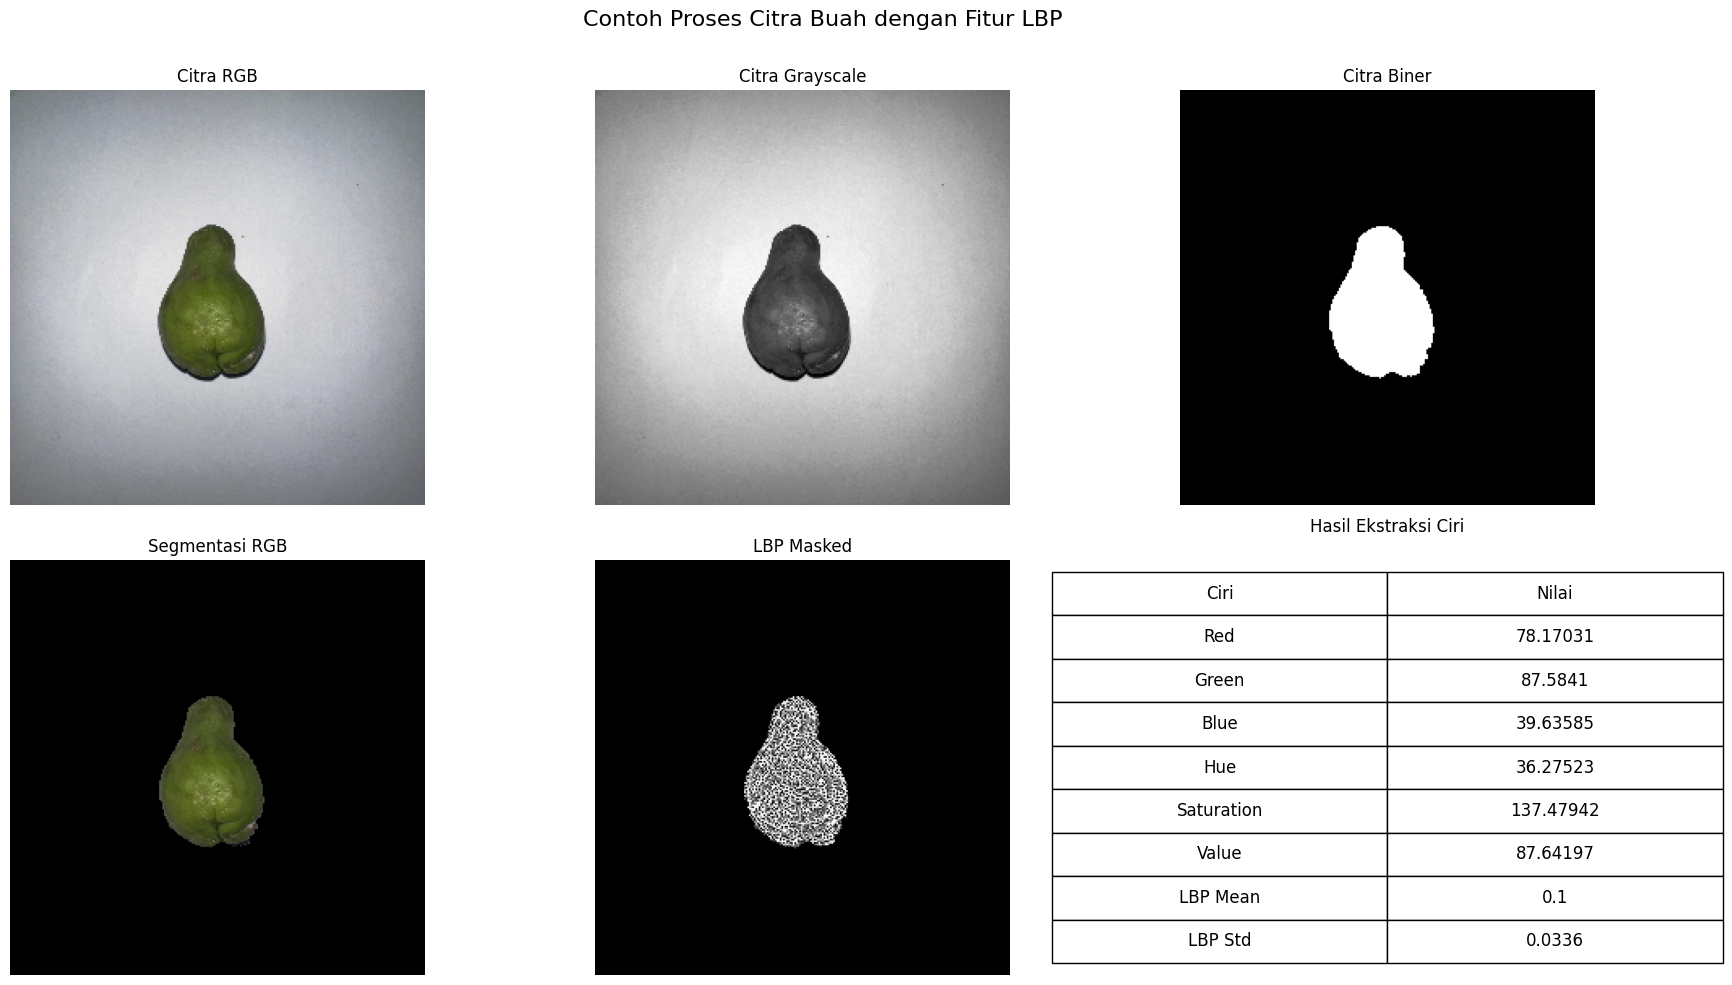

Memproses gambar: 100%|██████████| 1016/1016 [02:05<00:00,  8.09it/s]

Fitur (warna + LBP) berhasil disimpan di: /content/fitur_labu_siam.csv


In [ ]:
# === BAGIAN 1: IMPORT DAN SETUP ===
import cv2
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.feature import local_binary_pattern

# Folder input dan output
input_folder = '/content/drive/MyDrive/DML/Data_mining_lanjut/Dataset-Ilza JPG'
output_csv = '/content/fitur_labu_siam.csv'

# === BAGIAN 2: DEFINISI FUNGSI ===
def resize_gambar(image, target_size=(256, 256)):
    return cv2.resize(image, target_size)

def segmentasi_buah(image_bgr):
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lower_hsv = np.array([10, 40, 40])
    upper_hsv = np.array([180, 255, 255])
    mask = cv2.inRange(image_hsv, lower_hsv, upper_hsv)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def ekstrak_fitur(image_path):
    image_bgr = cv2.imread(image_path)
    image_resized = resize_gambar(image_bgr)
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)
    image_gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    mask = segmentasi_buah(image_resized)

    buah_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    buah_hsv = cv2.bitwise_and(image_hsv, image_hsv, mask=mask)
    buah_gray = cv2.bitwise_and(image_gray, image_gray, mask=mask)

    # Fitur warna
    buah_rgb_pixels = buah_rgb[mask > 0]
    buah_hsv_pixels = buah_hsv[mask > 0]
    mean_r = np.mean(buah_rgb_pixels[:, 0])
    mean_g = np.mean(buah_rgb_pixels[:, 1])
    mean_b = np.mean(buah_rgb_pixels[:, 2])
    mean_h = np.mean(buah_hsv_pixels[:, 0])
    mean_s = np.mean(buah_hsv_pixels[:, 1])
    mean_v = np.mean(buah_hsv_pixels[:, 2])

    # Fitur tekstur (LBP)
    if np.max(buah_gray) > 0:
        # Parameter LBP
        radius = 1
        n_points = 8 * radius
        lbp = local_binary_pattern(buah_gray, n_points, radius, method='uniform')

        # Hitung histogram LBP pada area bertopeng (mask)
        lbp_masked = lbp[mask > 0]
        n_bins = int(lbp.max() + 1)
        hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins), density=True)

        # Fitur LBP: statistik histogram dasar (mean, std)
        lbp_mean = np.mean(hist)
        lbp_std = np.std(hist)
    else:
        lbp_mean = 0.0
        lbp_std = 0.0

    return {
        'filename': os.path.basename(image_path),
        'mean_r': round(mean_r, 5),
        'mean_g': round(mean_g, 5),
        'mean_b': round(mean_b, 5),
        'mean_h': round(mean_h, 5),
        'mean_s': round(mean_s, 5),
        'mean_v': round(mean_v, 5),
        'lbp_mean': round(lbp_mean, 5),
        'lbp_std': round(lbp_std, 5)
    }

def tampilkan_visualisasi_contoh(image_path):
    image_bgr = cv2.imread(image_path)
    image_resized = resize_gambar(image_bgr)
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    image_hsv = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)
    mask = segmentasi_buah(image_resized)

    buah_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    buah_hsv = cv2.bitwise_and(image_hsv, image_hsv, mask=mask)
    buah_gray = cv2.bitwise_and(image_gray, image_gray, mask=mask)

    buah_rgb_pixels = buah_rgb[mask > 0]
    buah_hsv_pixels = buah_hsv[mask > 0]
    mean_r = np.mean(buah_rgb_pixels[:, 0])
    mean_g = np.mean(buah_rgb_pixels[:, 1])
    mean_b = np.mean(buah_rgb_pixels[:, 2])
    mean_h = np.mean(buah_hsv_pixels[:, 0])
    mean_s = np.mean(buah_hsv_pixels[:, 1])
    mean_v = np.mean(buah_hsv_pixels[:, 2])

    if np.max(buah_gray) > 0:
        radius = 1
        n_points = 8 * radius
        lbp = local_binary_pattern(buah_gray, n_points, radius, method='uniform')
        lbp_masked = lbp[mask > 0]
        n_bins = int(lbp.max() + 1)
        hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins), density=True)
        lbp_mean = np.mean(hist)
        lbp_std = np.std(hist)
    else:
        lbp_mean = 0.0
        lbp_std = 0.0

    fitur = {
        'Ciri': ['Red', 'Green', 'Blue', 'Hue', 'Saturation', 'Value',
                 'LBP Mean', 'LBP Std'],
        'Nilai': [round(mean_r, 5), round(mean_g, 5), round(mean_b, 5),
                  round(mean_h, 5), round(mean_s, 5), round(mean_v, 5),
                  round(lbp_mean, 5), round(lbp_std, 5)]
    }
    df_fitur = pd.DataFrame(fitur)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Contoh Proses Citra Buah dengan Fitur LBP", fontsize=16)

    axes[0, 0].imshow(image_rgb)
    axes[0, 0].set_title("Citra RGB")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(image_gray, cmap='gray')
    axes[0, 1].set_title("Citra Grayscale")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(mask, cmap='gray')
    axes[0, 2].set_title("Citra Biner")
    axes[0, 2].axis('off')

    axes[1, 0].imshow(buah_rgb)
    axes[1, 0].set_title("Segmentasi RGB")
    axes[1, 0].axis('off')

    lbp_display = np.zeros_like(buah_gray)
    lbp_display[mask > 0] = lbp[mask > 0]
    axes[1, 1].imshow(lbp_display, cmap='gray')
    axes[1, 1].set_title("LBP Masked")
    axes[1, 1].axis('off')

    axes[1, 2].axis('off')
    table = axes[1, 2].table(cellText=df_fitur.values,
                             colLabels=df_fitur.columns,
                             loc='center',
                             cellLoc='center')
    table.scale(1.2, 2.2)
    table.set_fontsize(12)
    axes[1, 2].set_title("Hasil Ekstraksi Ciri", pad=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# === BAGIAN 3: PROSES SEMUA GAMBAR DAN SIMPAN FITUR ===
image_files = [f for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
full_paths = [os.path.join(input_folder, fname) for fname in image_files]

data = []
for idx, img_path in enumerate(tqdm(full_paths, desc='Memproses gambar')):
    fitur = ekstrak_fitur(img_path)
    data.append(fitur)

    if idx == 0:
        tampilkan_visualisasi_contoh(img_path)

# Simpan ke CSV
df = pd.DataFrame(data)
df.to_csv(output_csv, index=False)
print(f"Fitur (warna + LBP) berhasil disimpan di: {output_csv}")


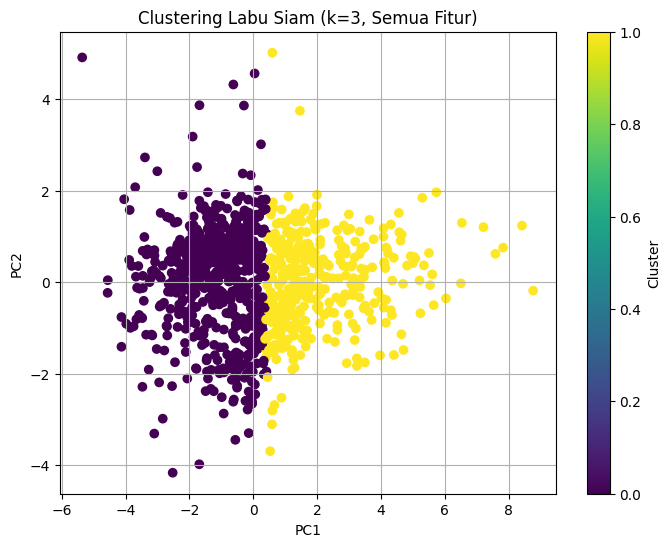

Hasil clustering disimpan di: /content/drive/MyDrive/DML/Data_mining_lanjut/cluster_labu_siam_k3_semua_fitur.csv
       filename     mean_r     mean_g    mean_b    mean_h     mean_s  \
0  IMG_7584.jpg   78.17031   87.58410  39.63585  36.27523  137.47942   
1  IMG_7595.jpg   59.49287   69.23420  32.74318  38.63321  132.16481   
2  IMG_7654.jpg  109.51232  111.78580  59.87516  31.43925  119.11775   
3  IMG_7623.jpg   84.54660   94.60607  43.55922  36.36553  136.60825   
4  IMG_7648.jpg   80.69555   91.24165  36.93045  36.07850  150.73211   
5  IMG_7645.jpg   98.51838  104.37415  50.45897  33.36795  129.00235   
6  IMG_7652.jpg   91.74159   98.21234  48.09299  34.05764  131.02764   
7  IMG_7653.jpg   83.26195   91.16794  49.67561  35.95176  120.01601   
8  IMG_7597.jpg   62.32912   72.18396  36.26006  38.36350  125.42786   
9  IMG_7521.jpg  119.95480  131.58415  60.79811  35.41076  135.15303   

      mean_v  lbp_std  cluster_num  
0   87.64197  0.03360            0  
1   69.28996  0.0281

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load data dari CSV
csv_path = '/content/drive/MyDrive/DML/Data_mining_lanjut/fitur_labu_siam.csv'
df = pd.read_csv(csv_path)

# 2. Gunakan semua fitur dari gambar
features = ['mean_r', 'mean_g', 'mean_b', 'mean_h', 'mean_s', 'mean_v', 'lbp_std']
X = df[features].values

# 3. Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Clustering dengan K-Means (k=3)
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster_num'] = kmeans.fit_predict(X_scaled)

# 5. Visualisasi hasil clustering dengan PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
df['PC1'], df['PC2'] = pcs[:, 0], pcs[:, 1]

# 6. Plot hasil clustering
plt.figure(figsize=(8, 6))
plt.scatter(df['PC1'], df['PC2'], c=df['cluster_num'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering Labu Siam (k=3, Semua Fitur)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

# 7. Simpan hasil
output_path = '/content/drive/MyDrive/DML/Data_mining_lanjut/cluster_labu_siam_k3_semua_fitur.csv'
df.to_csv(output_path, index=False)
print(f"Hasil clustering disimpan di: {output_path}")

# 8. Tampilkan 10 data pertama
print(df[['filename'] + features + ['cluster_num']].head(10))


In [ ]:
from sklearn.metrics import silhouette_score

# Ambil label hasil clustering
labels = kmeans.labels_

# Hitung Silhouette Score
score = silhouette_score(X_scaled, labels)

# Cetak hasil dengan k yang sebenarnya digunakan
print(f"Silhouette Score (k={kmeans.n_clusters}): {score:.3f}")


Silhouette Score (k=2): 0.312


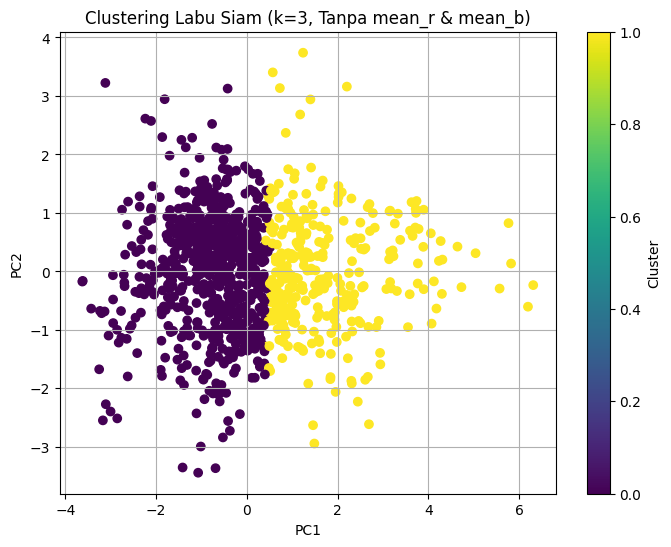

Hasil clustering disimpan di: /content/drive/MyDrive/DML/Data_mining_lanjut/cluster_labu_siam_k3_tanpa_r_b.csv
       filename     mean_g    mean_h     mean_s     mean_v  cluster_num
0  IMG_7584.jpg   87.58410  36.27523  137.47942   87.64197            0
1  IMG_7595.jpg   69.23420  38.63321  132.16481   69.28996            0
2  IMG_7654.jpg  111.78580  31.43925  119.11775  112.11900            1
3  IMG_7623.jpg   94.60607  36.36553  136.60825   94.65170            0
4  IMG_7648.jpg   91.24165  36.07850  150.73211   91.27047            0
5  IMG_7645.jpg  104.37415  33.36795  129.00235  104.50491            1
6  IMG_7652.jpg   98.21234  34.05764  131.02764   98.63745            0
7  IMG_7653.jpg   91.16794  35.95176  120.01601   91.31718            0
8  IMG_7597.jpg   72.18396  38.36350  125.42786   72.21599            0
9  IMG_7521.jpg  131.58415  35.41076  135.15303  131.58799            1


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load data dari CSV
csv_path = '/content/drive/MyDrive/DML/Data_mining_lanjut/fitur_labu_siam.csv'
df = pd.read_csv(csv_path)

# 2. Gunakan semua fitur warna KECUALI mean_r dan mean_b
features = ['mean_g', 'mean_h', 'mean_s', 'mean_v']  # mean_r dan mean_b dihapus
X = df[features].values

# 3. Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Clustering dengan K-Means (k=3)
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster_num'] = kmeans.fit_predict(X_scaled)

# 5. Visualisasi hasil clustering dengan PCA
pca = PCA(n_components=3)
pcs = pca.fit_transform(X_scaled)
df['PC1'], df['PC2'] = pcs[:, 0], pcs[:, 1]

# 6. Plot hasil clustering
plt.figure(figsize=(8, 6))
plt.scatter(df['PC1'], df['PC2'], c=df['cluster_num'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering Labu Siam (k=3, Tanpa mean_r & mean_b)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

# 7. Simpan hasil
output_path = '/content/drive/MyDrive/DML/Data_mining_lanjut/cluster_labu_siam_k3_tanpa_r_b.csv'
df.to_csv(output_path, index=False)
print(f"Hasil clustering disimpan di: {output_path}")

# 8. Tampilkan 10 data pertama
print(df[['filename', 'mean_g', 'mean_h', 'mean_s', 'mean_v', 'cluster_num']].head(10))


In [ ]:
from sklearn.metrics import silhouette_score

labels = kmeans.labels_

# Hitung Silhouette Score
score = silhouette_score(X_scaled, labels)

# Cetak hasilnya
print(f"Silhouette Score (k=2): {score:.3f}")


Silhouette Score (k=2): 0.336


In [ ]:
from sklearn.metrics import davies_bouldin_score

# Hitung Davies–Bouldin Index
dbi = davies_bouldin_score(X_scaled, kmeans.labels_)

# Cetak hasilnya
print(f"Davies–Bouldin Index: {dbi:.3f}")


Davies–Bouldin Index: 1.190
